In [2]:
# This is timport datarobot as dr
import pandas as pd
import numpy as np
from datetime import datetime
from scipy.stats import mode
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import sys, os
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import  ConfusionMatrixDisplay
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.inspection import permutation_importance
import xgboost as xgb
from scipy.stats import ks_2samp
from sklearn.model_selection import train_test_split

# Go up one directory from "notebooks" to project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

from scripts.modeling import (rank_models,
                              split_dataset,
                                plot_roc_curve_from_df) 


from scripts.utils import (save_file) 
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [3]:
# import sys
# print(sys.executable)

# !{sys.executable} -m pip install lightgbm

In [4]:
# import sys
# print(sys.executable)

# !{sys.executable} -m pip install xgboost

# 1 Ingests Data 

In [5]:
# Build base directory (go up one level from current /02_scripts)
base_dir = os.path.dirname(os.getcwd())   # → c:\Users\linoc\OneDrive\Encoder\03_partos
base_dir_raw =  Path(base_dir)
base_dir_raw= str(base_dir_raw.parents[1])

In [6]:
# Build the path to the target CSV
csv_path_Modulo1631_REC91_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1631_REC91_2024_M_clear.csv")
csv_path_Modulo1635_RE516171_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1635_RE516171_2024_M_clear.csv")
csv_path_Modulo1632_RE223132_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1632_RE223132_2024_M_clear.csv")
csv_path_Modulo1633_REC41_2024_fil_clear_v2 = os.path.join(base_dir,"data\\interim", "Modulo1633_REC41_2024_fil_clear_v2.csv")
csv_path_Modulo1633_REC94_2024_fil_clear_v2 = os.path.join(base_dir,"data\\interim", "Modulo1633_REC94_2024_fil_clear_v2.csv")
csv_path_Modulo1640_CSALUD01_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1640_CSALUD01_2024_M_clear.csv")
csv_path_target_final = os.path.join(base_dir,"data\\interim", "target_final.csv")

# Load the CSV into a DataFrame
Modulo1631_REC91_2024_M_clear = pd.read_csv(csv_path_Modulo1631_REC91_2024_M_clear, low_memory=False)
Modulo1635_RE516171_2024_M_clear= pd.read_csv(csv_path_Modulo1635_RE516171_2024_M_clear, low_memory=False)
Modulo1632_RE223132_2024_M_clear= pd.read_csv(csv_path_Modulo1632_RE223132_2024_M_clear, low_memory=False)
Modulo1633_REC41_2024_fil_clear_v2= pd.read_csv(csv_path_Modulo1633_REC41_2024_fil_clear_v2, low_memory=False)
Modulo1633_REC94_2024_fil_clear_v2= pd.read_csv(csv_path_Modulo1633_REC94_2024_fil_clear_v2, low_memory=False)
Modulo1640_CSALUD01_2024_M_clear= pd.read_csv(csv_path_Modulo1640_CSALUD01_2024_M_clear, low_memory=False)
target_final = pd.read_csv(csv_path_target_final, low_memory=False)


print(Modulo1631_REC91_2024_M_clear.shape)
print(Modulo1635_RE516171_2024_M_clear.shape)
print(Modulo1632_RE223132_2024_M_clear.shape)
print(Modulo1633_REC41_2024_fil_clear_v2.shape)
print(Modulo1633_REC94_2024_fil_clear_v2.shape) 
print(Modulo1640_CSALUD01_2024_M_clear.shape) 
print(target_final.shape) 

(37117, 132)
(34252, 63)
(34252, 65)
(16983, 463)
(16983, 280)
(34018, 153)
(18335, 5)


In [7]:
RANK_Modulo1631_REC91_2024_M_clear = ['SREGION','CASEID',
'S108N',
'S119',
'S119D',
'S704N',
'S816W',
'S816G',
'S816B',
'S816AL',
'S500B',
# 'S229A1',
# 'S229Y',
# 'S229A'
]

RANK_Modulo1635_RE516171_2024_M_clear =['CASEID',
    'V704',
'V715',
'V501',
'V716',
'V511',
'V631',
'V732',
'V504',
'V743F',
'V531',
'V525',
'V717',
'V743E',
'V743A',
'V702',
'V721',
'V705',

]
RANK_Modulo1632_RE223132_2024_M_clear = ['CASEID',
    'V212',
'V228',
'V218',
'V208',
'V217',
'V364',

]

RANK_Modulo1633_REC41_2024_fil_v2 =['CASEID',
    'M14',
'M13',
'M17',
'M1',
'M18',
'M19',
'M19A',
'M2C',
'M3C',
'M3G',
'M42A',
'M42B',
'M42C',
'M42D',
'M42E',
'M43',
'M44',
'M45',
'M46',
'M47',
'M48',
'M49A',
'M49B',
'M49C',
'M49D',
'M49X',
'M49Z',
'M57A',
'M57B',
'M60',
'M3A',
'M57I',
'M3H',
'M57O',
'M57G',
'M3B',
'M57M',
'M57K',
'M57X',
'M2B',
'M57Q',
'M57E',

]
RANK_Modulo1633_REC94_2024_fil_clear_v2 = ['CASEID',
'S410B',
'S411B',
'S411F',
'S411G',
'S411H',
'S411I',
'S411J',
'S411K',
'QI422A_A',
'QI422A_B',
'QI422A_C',
'QI422A_D',
'S426E',
'S426GE',
'S411BA',
'S413',
'S441',
'S411DA',
'S411EA',
'S411CA',
'S422I',


]
RANK_Modulo1640_CSALUD01_2024_M_clear =['HHID',
    'QS25N',
'QS22A',
'QS27_A',
'QS102',
'QS27_B',
'QS207C',
'QS109',
'QS27_BD',
'QS25AA',
'QS25BB',
'QS406',
'QS100',
#'QS103U',
'QS107',
# 'QS110U',
# 'QS202',
# 'QS203U',
# 'QS204C',
# 'QS205U',
'QS206',
'QS27_D',
'QS27_BC',
'QS25A',
'QS27_E',
'QS27_ ',
'QS25C5',
'QS25C3',

]

In [8]:
# keep all columns where name contains any of the patterns
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1633_REC41_2024_fil_v2])  # start-with pattern
# Add rule for exact match 'MIDX'
pattern = f'({pattern})|(^MIDX$)'
Modulo1633_REC41_2024_fil_clear_v2 = Modulo1633_REC41_2024_fil_clear_v2.filter(regex=pattern, axis=1)
Modulo1633_REC41_2024_fil_clear_v2.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 146 columns):
 #    Column     Dtype  
---   ------     -----  
 0    M11        float64
 1    M13        float64
 2    M14        float64
 3    M2B        float64
 4    M2C        float64
 5    M3A        int64  
 6    M3B        int64  
 7    M3C        int64  
 8    M3G        int64  
 9    M3H        int64  
 10   M17        int64  
 11   M57E       float64
 12   M57G       float64
 13   M57I       float64
 14   M57K       float64
 15   M57M       float64
 16   M57O       float64
 17   M57Q       float64
 18   M57X       float64
 19   M1_0       int64  
 20   M1_1       int64  
 21   M1_2       int64  
 22   M1_3       int64  
 23   M1_4       int64  
 24   M1_5       int64  
 25   M1_7       int64  
 26   M1_8       int64  
 27   M1_<NA>    int64  
 28   M1A_0      int64  
 29   M1A_1      int64  
 30   M1A_2      int64  
 31   M1A_3      int64  
 32   M1A_4      int64  
 33   M1A_5    

In [9]:
# keep all columns where name contains any of the patterns
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1633_REC94_2024_fil_clear_v2])  # start-with pattern
Modulo1633_REC94_2024_fil_clear_v2_filter = Modulo1633_REC94_2024_fil_clear_v2.filter(regex=pattern, axis=1)
Modulo1633_REC94_2024_fil_clear_v2_filter.info(verbose = True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 136 columns):
 #    Column         Dtype  
---   ------         -----  
 0    S411DA         float64
 1    S411CA         float64
 2    S422I          float64
 3    S411EA         float64
 4    S411BA         float64
 5    S413           float64
 6    S426E          float64
 7    S426GE         float64
 8    S441           int64  
 9    S410B_1        int64  
 10   S410B_2        int64  
 11   S410B_3        int64  
 12   S410B_4        int64  
 13   S410B_5        int64  
 14   S410B_6        int64  
 15   S410B_7        int64  
 16   S410B_8        int64  
 17   S410B_9        int64  
 18   S410B_98       int64  
 19   S410B_<NA>     int64  
 20   S411B_0        int64  
 21   S411B_1        int64  
 22   S411B_8        int64  
 23   S411B_<NA>     int64  
 24   S411F_0        int64  
 25   S411F_1        int64  
 26   S411F_8        int64  
 27   S411F_<NA>     int64  
 28   S411G_0       

# 2 Consolidate Datasets

In [10]:
target_final.CASEID.nunique()

18335

In [11]:
data_train = target_final.merge(Modulo1631_REC91_2024_M_clear[RANK_Modulo1631_REC91_2024_M_clear].rename(
    columns={col: f"REC91_{col}" if col not in ["CASEID"] else col for col in Modulo1631_REC91_2024_M_clear[RANK_Modulo1631_REC91_2024_M_clear].columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()

18335

In [12]:
data_train = data_train.merge(Modulo1635_RE516171_2024_M_clear[RANK_Modulo1635_RE516171_2024_M_clear].rename(
    columns={col: f"RE516171_{col}" if col not in ["CASEID"] else col for col in Modulo1635_RE516171_2024_M_clear[RANK_Modulo1635_RE516171_2024_M_clear].columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()


18335

In [13]:
# keep all columns where name contains any of the patterns
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1633_REC41_2024_fil_v2])  # start-with pattern
Modulo1633_REC41_2024_fil_clear_v2_filter = Modulo1633_REC41_2024_fil_clear_v2.filter(regex=pattern, axis=1)
Modulo1633_REC41_2024_fil_clear_v2_filter.info(verbose = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 146 columns):
 #    Column     Dtype  
---   ------     -----  
 0    M11        float64
 1    M13        float64
 2    M14        float64
 3    M2B        float64
 4    M2C        float64
 5    M3A        int64  
 6    M3B        int64  
 7    M3C        int64  
 8    M3G        int64  
 9    M3H        int64  
 10   M17        int64  
 11   M57E       float64
 12   M57G       float64
 13   M57I       float64
 14   M57K       float64
 15   M57M       float64
 16   M57O       float64
 17   M57Q       float64
 18   M57X       float64
 19   M1_0       int64  
 20   M1_1       int64  
 21   M1_2       int64  
 22   M1_3       int64  
 23   M1_4       int64  
 24   M1_5       int64  
 25   M1_7       int64  
 26   M1_8       int64  
 27   M1_<NA>    int64  
 28   M1A_0      int64  
 29   M1A_1      int64  
 30   M1A_2      int64  
 31   M1A_3      int64  
 32   M1A_4      int64  
 33   M1A_5    

In [14]:
data_train = data_train.merge(Modulo1633_REC41_2024_fil_clear_v2_filter.rename(
    columns={col: f"REC41_{col}" if col not in ["CASEID"] else col for col in Modulo1633_REC41_2024_fil_clear_v2_filter.columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()

18335

In [15]:
# Modulo1633_REC94_2024_fil_clear_v2.drop(['Q220A',
#                                          'BIDX',
#                                          'IDX94_x',
#                                          'IDX94_y',
#                                          'premature_flag_x',
#                                          'premature_flag_y',
#                                          'BIDX_x_1','BIDX_x_2','BIDX_x_3','BIDX_x_4','BIDX_x_5','',''])

# keep all columns where name contains any of the patterns
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1633_REC94_2024_fil_clear_v2])  # start-with pattern
Modulo1633_REC94_2024_fil_clear_v2_filter = Modulo1633_REC94_2024_fil_clear_v2.filter(regex=pattern, axis=1)
Modulo1633_REC94_2024_fil_clear_v2_filter.info(verbose = True)

data_train = data_train.merge(Modulo1633_REC94_2024_fil_clear_v2_filter.rename(
    columns={col: f"REC94_{col}" if col not in ["CASEID"] else col for col in Modulo1633_REC94_2024_fil_clear_v2_filter.columns}),
                                 on='CASEID', 
                                 how='left')
data_train.CASEID.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 136 columns):
 #    Column         Dtype  
---   ------         -----  
 0    S411DA         float64
 1    S411CA         float64
 2    S422I          float64
 3    S411EA         float64
 4    S411BA         float64
 5    S413           float64
 6    S426E          float64
 7    S426GE         float64
 8    S441           int64  
 9    S410B_1        int64  
 10   S410B_2        int64  
 11   S410B_3        int64  
 12   S410B_4        int64  
 13   S410B_5        int64  
 14   S410B_6        int64  
 15   S410B_7        int64  
 16   S410B_8        int64  
 17   S410B_9        int64  
 18   S410B_98       int64  
 19   S410B_<NA>     int64  
 20   S411B_0        int64  
 21   S411B_1        int64  
 22   S411B_8        int64  
 23   S411B_<NA>     int64  
 24   S411F_0        int64  
 25   S411F_1        int64  
 26   S411F_8        int64  
 27   S411F_<NA>     int64  
 28   S411G_0       

18335

In [16]:
# Clean CASEID to keep only the first numeric part before space
data_train['CASEID_HHID'] = data_train['CASEID'].astype(str).str.split().str[0]
data_train['CASEID_HHID'] = data_train['CASEID_HHID'].astype(int)

data_train.head()

,CASEID,BIDX,Q220A,premature,premature_flag,REC91_SREGION,REC91_S108N,REC91_S119,REC91_S119D,REC91_S704N,REC91_S816W,REC91_S816G,REC91_S816B,REC91_S816AL,REC91_S500B,RE516171_V704,RE516171_V715,RE516171_V501,RE516171_V716,RE516171_V511,RE516171_V631,RE516171_V732,RE516171_V504,RE516171_V743F,RE516171_V531,RE516171_V525,RE516171_V717,RE516171_V743E,RE516171_V743A,RE516171_V702,RE516171_V721,RE516171_V705,REC41_M11,REC41_M13,REC41_M14,REC41_M2B,REC41_M2C,REC41_M3A,REC41_M3B,REC41_M3C,REC41_M3G,REC41_M3H,REC41_M17,REC41_M57E,REC41_M57G,REC41_M57I,REC41_M57K,REC41_M57M,REC41_M57O,REC41_M57Q,REC41_M57X,REC41_M1_0,REC41_M1_1,REC41_M1_2,REC41_M1_3,REC41_M1_4,REC41_M1_5,REC41_M1_7,REC41_M1_8,REC41_M1_<NA>,REC41_M1A_0,REC41_M1A_1,REC41_M1A_2,REC41_M1A_3,REC41_M1A_4,REC41_M1A_5,REC41_M1A_6,REC41_M1A_7,REC41_M1A_8,REC41_M1A_<NA>,REC41_M1B_1,REC41_M1B_10,REC41_M1B_11,REC41_M1B_12,REC41_M1B_2,REC41_M1B_3,REC41_M1B_4,REC41_M1B_5,REC41_M1B_6,REC41_M1B_7,REC41_M1B_8,REC41_M1B_9,REC41_M1B_98,REC41_M1B_<NA>,REC41_M1D_1,REC41_M1D_10,REC41_M1D_11,REC41_M1D_12,REC41_M1D_13,REC41_M1D_14,REC41_M1D_15,REC41_M1D_16,REC41_M1D_17,REC41_M1D_18,REC41_M1D_2,REC41_M1D_20,REC41_M1D_22,REC41_M1D_24,REC41_M1D_25,REC41_M1D_27,REC41_M1D_3,REC41_M1D_4,REC41_M1D_5,REC41_M1D_6,REC41_M1D_7,REC41_M1D_8,REC41_M1D_9,REC41_M1D_98,REC41_M1D_<NA>,REC41_M10_1,REC41_M10_2,REC41_M10_3,REC41_M15_11,REC41_M15_12,REC41_M15_21,REC41_M15_22,REC41_M15_23,REC41_M15_24,REC41_M15_25,REC41_M15_26,REC41_M15_27,REC41_M15_31,REC41_M15_32,REC41_M15_41,REC41_M15_42,REC41_M15_96,REC41_M18_1,REC41_M18_2,REC41_M18_3,REC41_M18_4,REC41_M18_5,REC41_M18_8,REC41_M19A_0,REC41_M19A_1,REC41_M19A_2,REC41_M19A_8,REC41_M19A_<NA>,REC41_M42A_0,REC41_M42A_1,REC41_M42A_8,REC41_M42A_<NA>,REC41_M42C_0,REC41_M42C_1,REC41_M42C_8,REC41_M42C_<NA>,REC41_M42D_0,REC41_M42D_1,REC41_M42D_8,REC41_M42D_<NA>,REC41_M42E_0,REC41_M42E_1,REC41_M42E_8,REC41_M42E_<NA>,REC41_M43_0,REC41_M43_1,REC41_M43_8,REC41_M43_<NA>,REC41_M44_0,REC41_M44_1,REC41_M44_8,REC41_M44_<NA>,REC41_M45_0,REC41_M45_1,REC41_M45_8,REC41_M45_<NA>,REC41_M47_0,REC41_M47_1,REC41_M47_8,REC41_M47_<NA>,REC41_M48_0,REC41_M48_1,REC41_M48_8,REC41_M48_<NA>,REC41_M60_0,REC41_M60_1,REC41_M60_8,REC41_M60_<NA>,REC94_S411DA,REC94_S411CA,REC94_S422I,REC94_S411EA,REC94_S411BA,REC94_S413,REC94_S426E,REC94_S426GE,REC94_S441,REC94_S410B_1,REC94_S410B_2,REC94_S410B_3,REC94_S410B_4,REC94_S410B_5,REC94_S410B_6,REC94_S410B_7,REC94_S410B_8,REC94_S410B_9,REC94_S410B_98,REC94_S410B_<NA>,REC94_S411B_0,REC94_S411B_1,REC94_S411B_8,REC94_S411B_<NA>,REC94_S411F_0,REC94_S411F_1,REC94_S411F_8,REC94_S411F_<NA>,REC94_S411G_0,REC94_S411G_1,REC94_S411G_8,REC94_S411G_<NA>,REC94_S411H_0,REC94_S411H_1,REC94_S411H_8,REC94_S411H_<NA>,REC94_S411I_0,REC94_S411I_1,REC94_S411I_8,REC94_S411I_<NA>,REC94_S411J_0,REC94_S411J_1,REC94_S411J_8,REC94_S411J_<NA>,REC94_S411K_0,REC94_S411K_1,REC94_S411K_8,REC94_S411K_<NA>,REC94_S411BA_0,REC94_S411BA_1,REC94_S411BA_2,REC94_S411BA_3,REC94_S411BA_4,REC94_S411BA_5,REC94_S411BA_6,REC94_S411BA_7,REC94_S411BA_8,REC94_S411BA_9,REC94_S411BA_98,REC94_S411BA_<NA>,REC94_S411CA_0,REC94_S411CA_1,REC94_S411CA_2,REC94_S411CA_3,REC94_S411CA_4,REC94_S411CA_5,REC94_S411CA_6,REC94_S411CA_7,REC94_S411CA_8,REC94_S411CA_9,REC94_S411CA_98,REC94_S411CA_<NA>,REC94_S411DA_0,REC94_S411DA_1,REC94_S411DA_2,REC94_S411DA_3,REC94_S411DA_4,REC94_S411DA_5,REC94_S411DA_6,REC94_S411DA_7,REC94_S411DA_8,REC94_S411DA_9,REC94_S411DA_98,REC94_S411DA_<NA>,REC94_S411EA_0,REC94_S411EA_1,REC94_S411EA_2,REC94_S411EA_3,REC94_S411EA_4,REC94_S411EA_5,REC94_S411EA_6,REC94_S411EA_7,REC94_S411EA_8,REC94_S411EA_9,REC94_S411EA_98,REC94_S411EA_<NA>,REC94_S422I_0,REC94_S422I_1,REC94_S422I_10,REC94_S422I_12,REC94_S422I_14,REC94_S422I_15,REC94_S422I_16,REC94_S422I_18,REC94_S422I_2,REC94_S422I_20,REC94_S422I_24,REC94_S422I_3,REC94_S422I_30,REC94_S422I_36,REC94_S422I_4,REC94_S422I_5,REC94_S422I_6,REC94_S422I_60,REC94_S422I_7,REC94_S422I_8,REC94_S422I_80,REC94_S422I_9,REC94_S422I_98,REC94_S422I_<NA>,REC94_QI422A_A_1,REC94_

In [17]:
pattern = '|'.join([f'^{x}' for x in RANK_Modulo1640_CSALUD01_2024_M_clear])  # start-with pattern
Modulo1640_CSALUD01_2024_M_clear_filter = Modulo1640_CSALUD01_2024_M_clear.filter(regex=pattern, axis=1)



data_train = data_train.merge(Modulo1640_CSALUD01_2024_M_clear_filter.rename(
    columns={col: f"CSALUD01_{col}" if col not in ["HHID"] else col for col in Modulo1640_CSALUD01_2024_M_clear_filter.columns}),
                                 left_on='CASEID_HHID', right_on = 'HHID' ,
                                 how='left')

data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 337 columns):
 #    Column               Non-Null Count  Dtype  
---   ------               --------------  -----  
 0    CASEID               18335 non-null  object 
 1    BIDX                 18335 non-null  int64  
 2    Q220A                18335 non-null  int64  
 3    premature            18335 non-null  int64  
 4    premature_flag       18335 non-null  int64  
 5    REC91_SREGION        18335 non-null  float64
 6    REC91_S108N          18335 non-null  float64
 7    REC91_S119           18335 non-null  float64
 8    REC91_S119D          18335 non-null  float64
 9    REC91_S704N          18335 non-null  float64
 10   REC91_S816W          18335 non-null  int64  
 11   REC91_S816G          18335 non-null  int64  
 12   REC91_S816B          18335 non-null  int64  
 13   REC91_S816AL         18335 non-null  int64  
 14   REC91_S500B          18335 non-null  int64  
 15   RE516171_V704    

In [18]:
data_train.columns = data_train.columns.str.replace('<NA>', 'NA')
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18335 entries, 0 to 18334
Data columns (total 337 columns):
 #    Column             Non-Null Count  Dtype  
---   ------             --------------  -----  
 0    CASEID             18335 non-null  object 
 1    BIDX               18335 non-null  int64  
 2    Q220A              18335 non-null  int64  
 3    premature          18335 non-null  int64  
 4    premature_flag     18335 non-null  int64  
 5    REC91_SREGION      18335 non-null  float64
 6    REC91_S108N        18335 non-null  float64
 7    REC91_S119         18335 non-null  float64
 8    REC91_S119D        18335 non-null  float64
 9    REC91_S704N        18335 non-null  float64
 10   REC91_S816W        18335 non-null  int64  
 11   REC91_S816G        18335 non-null  int64  
 12   REC91_S816B        18335 non-null  int64  
 13   REC91_S816AL       18335 non-null  int64  
 14   REC91_S500B        18335 non-null  int64  
 15   RE516171_V704      18335 non-null  float64
 16   RE

# 3 Modeling

In [19]:
data_train = data_train.dropna()
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 16983 entries, 0 to 18334
Data columns (total 337 columns):
 #    Column             Non-Null Count  Dtype  
---   ------             --------------  -----  
 0    CASEID             16983 non-null  object 
 1    BIDX               16983 non-null  int64  
 2    Q220A              16983 non-null  int64  
 3    premature          16983 non-null  int64  
 4    premature_flag     16983 non-null  int64  
 5    REC91_SREGION      16983 non-null  float64
 6    REC91_S108N        16983 non-null  float64
 7    REC91_S119         16983 non-null  float64
 8    REC91_S119D        16983 non-null  float64
 9    REC91_S704N        16983 non-null  float64
 10   REC91_S816W        16983 non-null  int64  
 11   REC91_S816G        16983 non-null  int64  
 12   REC91_S816B        16983 non-null  int64  
 13   REC91_S816AL       16983 non-null  int64  
 14   REC91_S500B        16983 non-null  int64  
 15   RE516171_V704      16983 non-null  float64
 16   RE51617

In [20]:
tem_data_train= data_train.drop(columns =['CASEID']) 


In [21]:
def get_high_corr_features(df, target='premature_flag', threshold=0.5):
    corr_matrix = df.corr()
    if target not in corr_matrix.columns:
        raise ValueError(f"Target '{target}' not found in DataFrame columns.")
    corrs = corr_matrix[target].abs()
    high_corr_features = corrs[corrs > threshold].index.tolist()
    high_corr_features.remove(target)  # Remove the target itself
    return high_corr_features

In [22]:
feature_corr = get_high_corr_features(tem_data_train, target='premature_flag', threshold=0.5)
feature_corr.append('premature_flag')


In [23]:
feature_corr

['Q220A', 'premature', 'REC94_S410B_8', 'REC94_S410B_9', 'premature_flag']

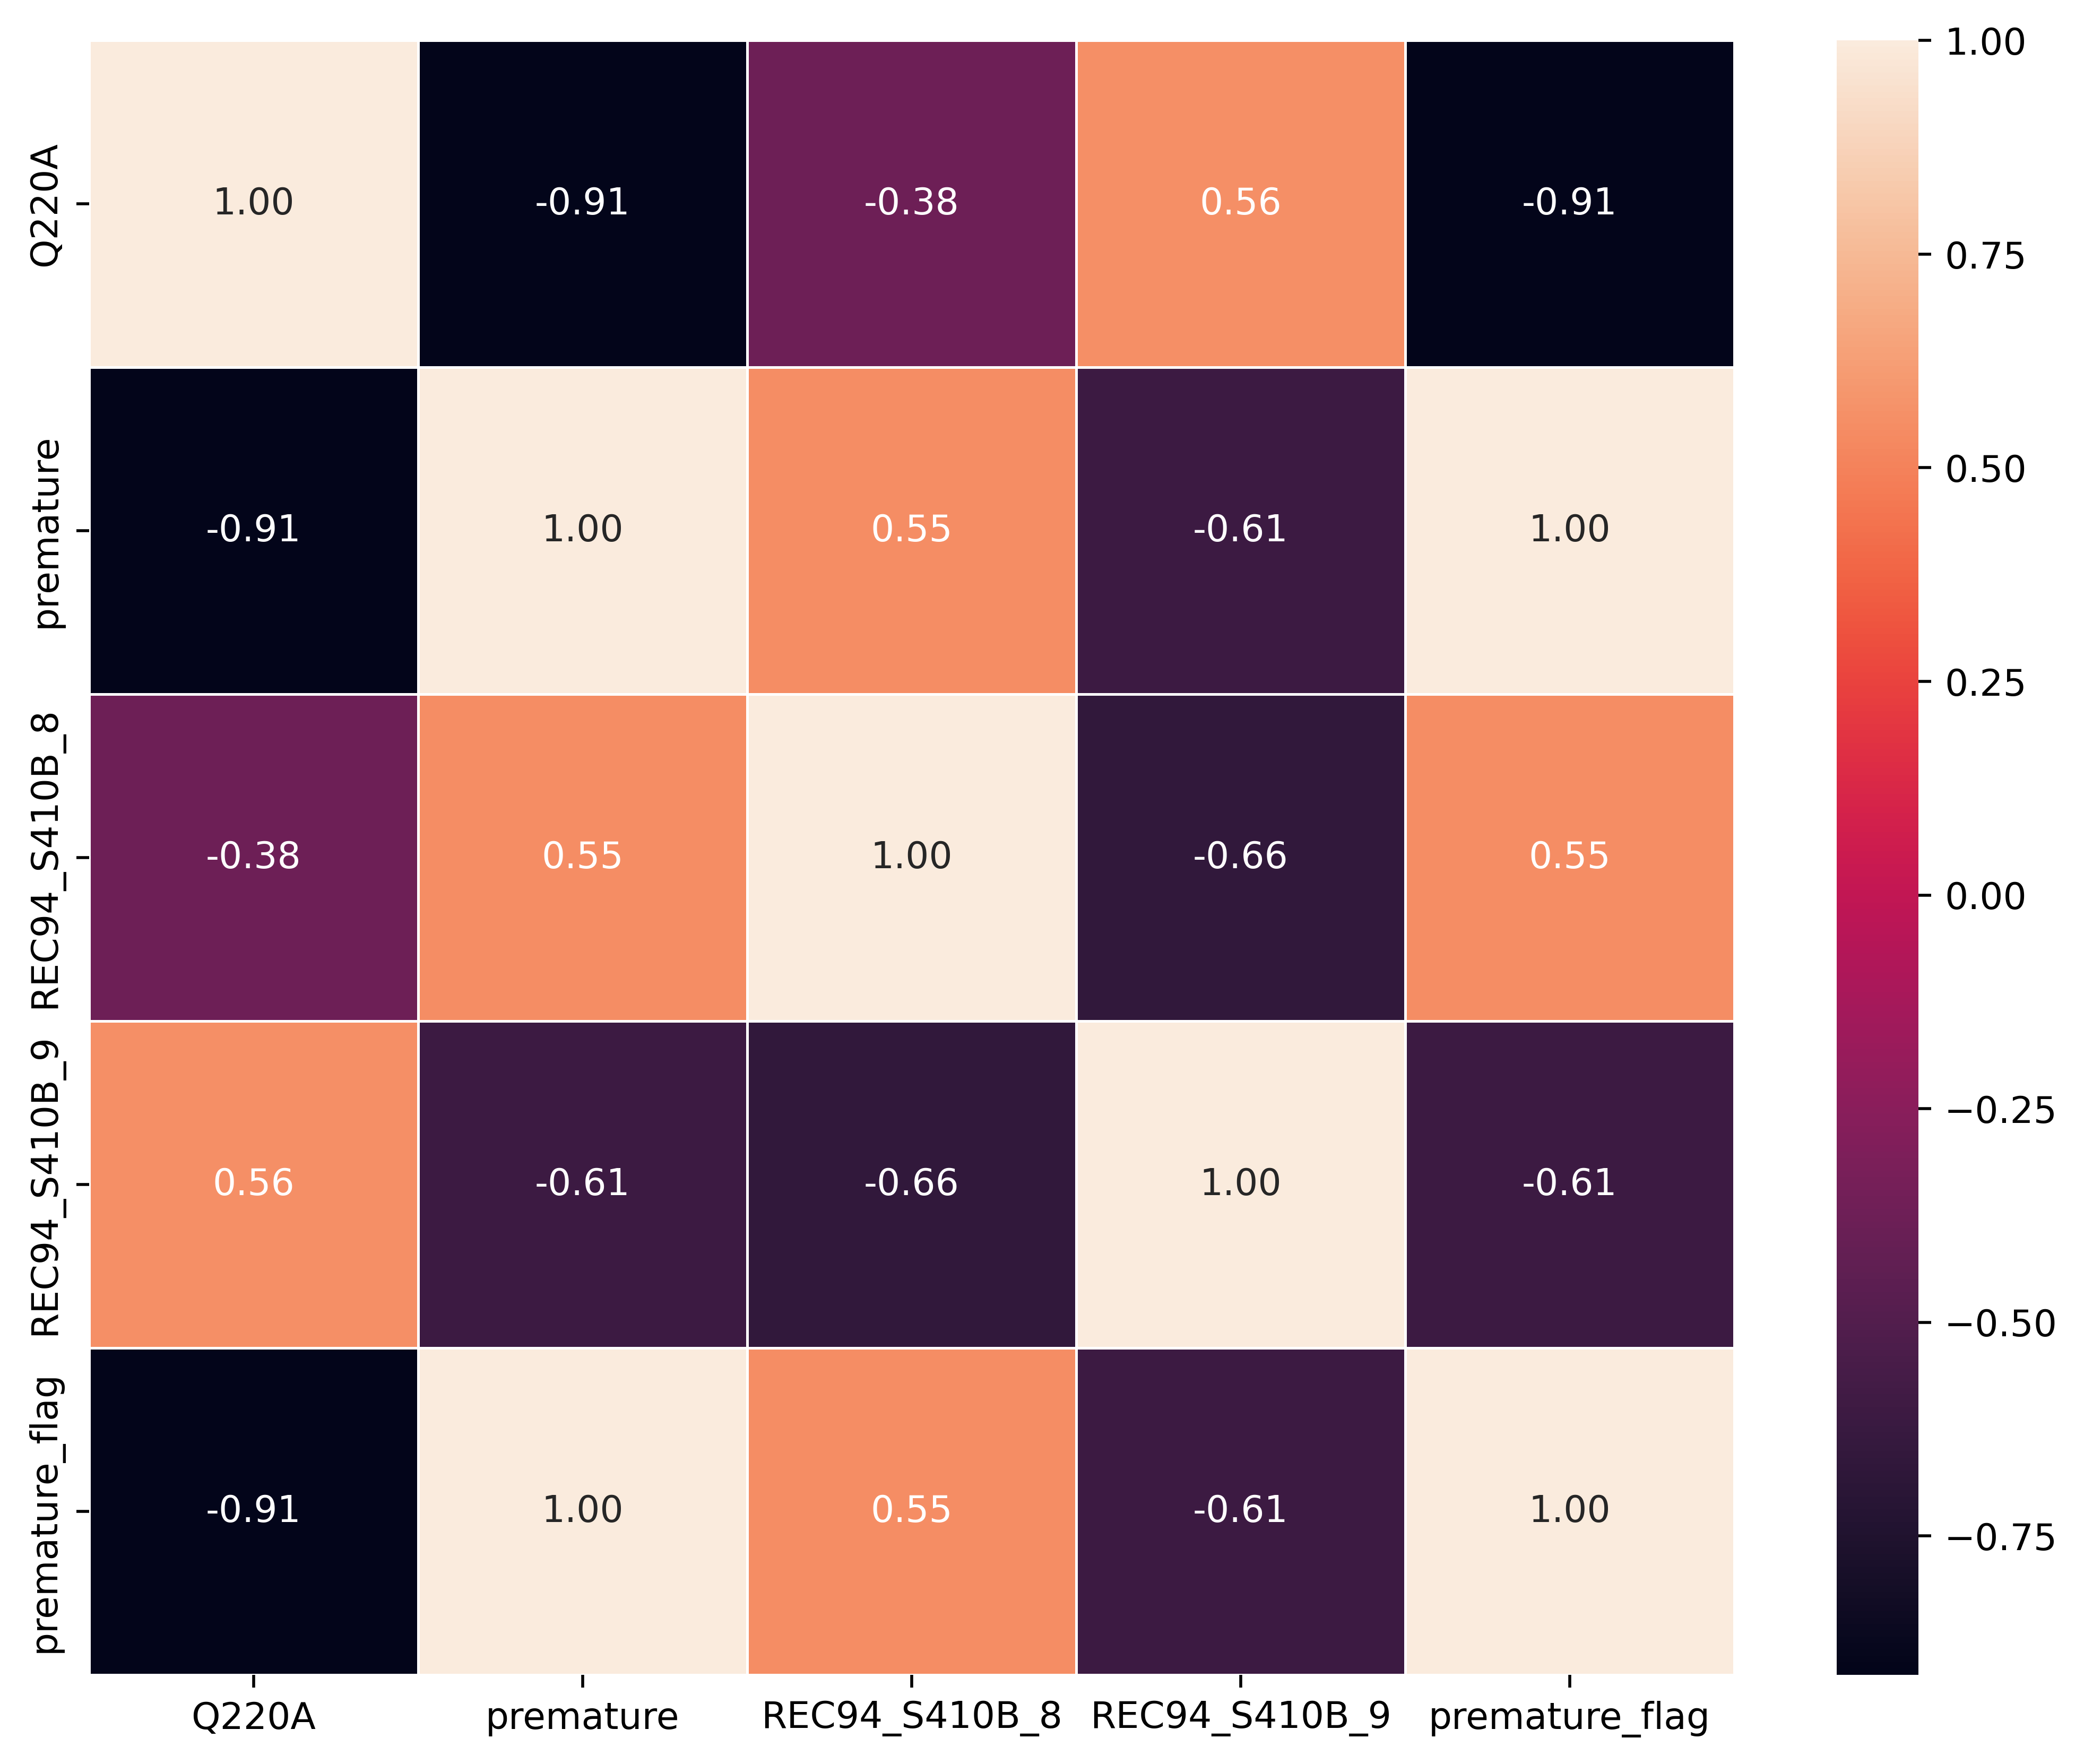

In [24]:
corr = tem_data_train[feature_corr].corr(method = 'pearson')
plt.figure(figsize=(10,8), dpi =500)
sns.heatmap(corr,annot=True,fmt=".2f", linewidth=.5)
plt.show()

In [25]:
remove_columns =['HHID',
                 'CASEID',
                   'BIDX',
                     'Q220A',
                       'premature', 
                       'CASEID_HHID',
                       'REC94_S410B_8',
                         'REC94_S410B_9']
data_train =data_train.drop(columns=remove_columns)
data_train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 16983 entries, 0 to 18334
Data columns (total 329 columns):
 #    Column             Non-Null Count  Dtype  
---   ------             --------------  -----  
 0    premature_flag     16983 non-null  int64  
 1    REC91_SREGION      16983 non-null  float64
 2    REC91_S108N        16983 non-null  float64
 3    REC91_S119         16983 non-null  float64
 4    REC91_S119D        16983 non-null  float64
 5    REC91_S704N        16983 non-null  float64
 6    REC91_S816W        16983 non-null  int64  
 7    REC91_S816G        16983 non-null  int64  
 8    REC91_S816B        16983 non-null  int64  
 9    REC91_S816AL       16983 non-null  int64  
 10   REC91_S500B        16983 non-null  int64  
 11   RE516171_V704      16983 non-null  float64
 12   RE516171_V715      16983 non-null  float64
 13   RE516171_V501      16983 non-null  float64
 14   RE516171_V716      16983 non-null  float64
 15   RE516171_V511      16983 non-null  float64
 16   RE51617

In [26]:
data_train['premature_flag'].value_counts()

premature_flag
0    13686
1     3297
Name: count, dtype: int64

In [27]:
df_train_test , df_holdout = train_test_split(data_train, test_size=0.1, random_state=42)  # random_state for reproducibility

train_data, test_data, train_labels, test_labels,features = split_dataset(df_train_test, remove_columns=None, target_variable='premature_flag')

holdout_data = df_holdout[features]
holdout_labels= df_holdout['premature_flag']


Train shape: (11887, 328), Test shape: (3397, 328)
Train labels shape: (11887,), Test labels shape: (3397,)
Features used: 328


In [28]:
holdout_data.shape, holdout_labels.shape

((1699, 328), (1699,))

In [29]:
print(train_labels.value_counts(1)), 
print(test_labels.value_counts(1)), 
print(holdout_labels.value_counts(1)), 


premature_flag
0    0.806595
1    0.193405
Name: proportion, dtype: float64
premature_flag
0    0.806594
1    0.193406
Name: proportion, dtype: float64
premature_flag
0    0.799294
1    0.200706
Name: proportion, dtype: float64


(None,)

In [30]:
result = rank_models(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels)

c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 2299, number of negative: 9588
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005840 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 938
[LightGBM] [Info] Number of data points in the train set: 11887, number of used features: 244
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193405 -> initscore=-1.428038
[LightGBM] [Info] Start training from score -1.428038


In [31]:
result

,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier,Test,0.8293,0.3333,0.6066,0.4303,0.4006,0.7617,1
1,XGBClassifier,Holdout,0.8175,0.3314,0.5795,0.4216,0.4066,0.7717,2
10,SVM,Test,0.7436,0.6271,0.3969,0.4861,0.4114,0.7658,3
11,SVM,Holdout,0.7375,0.6716,0.4067,0.5066,0.4342,0.7871,4
6,RandomForest,Test,0.8319,0.1659,0.8258,0.2763,0.4106,0.7653,5
7,RandomForest,Holdout,0.8228,0.1466,0.8333,0.2494,0.4112,0.7828,6
2,LogisticRegression,Test,0.7304,0.6743,0.3869,0.4917,0.4236,0.7784,7
3,LogisticRegression,Holdout,0.7251,0.7009,0.3957,0.5058,0.4493,0.7961,8
4,LightGBM,Test,0.8384,0.3120,0.6788,0.4275,0.4260,0.7803,9
5,LightGBM,Holdout,0.8258,0.3138,0.6331,0.4196,0.4334,0.7944,10


In [ ]:



def train_xgb_gridsearch_and_rank(train_data, 
                                  train_labels, 
                                  test_data, 
                                  test_labels, 
                                  holdout_data, 
                                  holdout_labels,
                                  early_stopping_rounds=None):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos
    print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )

    # Parameter grid (customize as needed)
    param_grid = {
        'n_estimators': [800,1000,1200],
        'max_depth': [ 3,6,9],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, train_data, y_train, 'Training'),
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
       
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params




def train_xgb_gridsearch_and_rank_stopp(train_data, 
                                  train_labels, 
                                  test_data, 
                                  test_labels, 
                                  holdout_data, 
                                  holdout_labels,
                                  early_stopping_rounds=early_stopping_rounds):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos
    print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )


    xgb_model.fit(train_data, 
                   y_train,
                   early_stopping_rounds=early_stopping_rounds,
                   verbose=True)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, train_data, y_train, 'Training'),
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
       
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return xgb_model, results_df



def train_xgb_gridsearch_and_rank_v2(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    # neg, pos = np.bincount(y_train)
    # scale_pos_weight = neg / pos
    # print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        #scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )

    # Parameter grid (customize as needed)
    param_grid = {
        'n_estimators': [800,1000,1500,2000],
        'max_depth': [ 3,6,9],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, train_data, y_train, 'Training'),
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
       
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params




def train_xgb_gridsearch_and_rank_v3(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    # neg, pos = np.bincount(y_train)
    # scale_pos_weight = neg / pos
    # print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        #scale_pos_weight=scale_pos_weight,
        use_label_encoder=False
    )
    

    # Parameter grid (customize as needed)
    param_grid = {
        'n_estimators': [800,1000,1500,2000],
        'max_depth': [ 3,6,9],
        'learning_rate': [0.01],
        #'subsample': [0.7, 0.8, 1.0],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=123)

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params


def train_xgb_gridsearch_and_rank_v4(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels):
    """
    Performs GridSearchCV tuning for XGBClassifier, fits the best model,
    and evaluates it on Test and Holdout datasets.
    Returns both the trained model and a metrics DataFrame.
    """

    # Convert labels to 1D array
    y_train = np.ravel(train_labels)
    y_test = np.ravel(test_labels)
    y_holdout = np.ravel(holdout_labels)

    # Handle imbalance
    neg, pos = np.bincount(y_train)
    scale_pos_weight = neg / pos
    print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

    # Base model
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=123,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        tree_method="hist",
        grow_policy="lossguide"
    )

    # Parameter grid (customize as needed)
    param_grid = {
        'n_estimators': [800,1200,1600],
        'max_depth': [ 3,5,7],
        'learning_rate': [0.01],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'min_child_weight': [1],
        'gamma': [0]
    }

    # GridSearchCV setup
    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=3,
        verbose=2,
        n_jobs=-1
    )

    # Run grid search
    grid_search.fit(train_data, y_train)
    best_params = grid_search.best_params_
    print("✅ Best Parameters Found:")
    for k, v in best_params.items():
        print(f"   {k}: {v}")
    print(f"🏆 Best CV ROC-AUC: {grid_search.best_score_:.4f}")

    # Retrain best model on full training set
    best_model = grid_search.best_estimator_
    best_model.fit(train_data, y_train)

    # Helper to evaluate metrics
    def evaluate(model, X, y, dataset_type):
        preds = model.predict(X)
        probs = model.predict_proba(X)[:, 1]

        accuracy = accuracy_score(y, preds)
        recall = recall_score(y, preds)
        precision = precision_score(y, preds)
        f1 = f1_score(y, preds)
        roc_auc = roc_auc_score(y, probs)

        # KS statistic
        positive_probs = probs[y == 1]
        negative_probs = probs[y == 0]
        ks_stat = ks_2samp(positive_probs, negative_probs).statistic

        return {
            'Model': 'XGBClassifier (GridSearch)',
            'dataset_type': dataset_type,
            'Accuracy': accuracy,
            'Recall': recall,
            'Precision': precision,
            'F1 Score': f1,
            'KS Stat': ks_stat,
            'ROC AUC': roc_auc
        }

    # Evaluate on Test & Holdout
    results = [
        evaluate(best_model, test_data, y_test, 'Test'),
        evaluate(best_model, holdout_data, y_holdout, 'Holdout')
    ]

    # Format results table
    results_df = pd.DataFrame(results)
    results_df['Rank'] = range(1, len(results_df) + 1)
    results_df = results_df.round(4)

    return best_model, results_df, best_params


In [62]:
def perm_importance_test(
    model,
    test_data,
    test_labels,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
):
    """
    Compute permutation importance for a trained model using only the Test dataset.

    Parameters
    ----------
    model : fitted model
        Any trained sklearn-compatible model with .predict_proba().
    test_data : DataFrame
        Features of the test dataset.
    test_labels : Series or array
        Target labels for the test dataset.
    scoring : str, default='roc_auc'
        Metric to evaluate permutation importance.
    n_repeats : int, default=10
        Number of shuffles per feature.
    random_state : int, default=42
        Seed for reproducibility.

    Returns
    -------
    df_imp : DataFrame
        Feature importance ranked by mean decrease in performance.
        Columns: ['rank', 'feature', 'importance_mean', 'importance_std']
    result : sklearn permutation_importance object
        Full result for advanced analysis or plotting.
    """

    # Ensure correct label shape
    y_test = np.ravel(test_labels)

    print("🔹 Computing permutation importance on TEST set...")
    result = permutation_importance(
        model,
        test_data,
        y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    # Build importance DataFrame
    df_rank = pd.DataFrame({
        "feature": test_data.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    df_rank["rank"] = np.arange(1, len(df_rank) + 1)
    df_rank = df_rank[["rank", "feature", "importance_mean", "importance_std"]]

    print("✅ Permutation importance completed on TEST dataset.")
    return df_rank, result


In [ ]:
def model_curve_plot_logloss_error(model, train_data, train_labels, test_data, test_labels):
    """
    Train an XGBoost model and plot LogLoss and Classification Error
    curves for Train vs. Test sets.
    """

    # Force model to track logloss + error
    model.set_params(eval_metric=["logloss", "error"])

    eval_set = [(train_data, train_labels), (test_data, test_labels)]

    # Fit model
    model.fit(train_data, train_labels, eval_set=eval_set, verbose=True)

    # Evaluate accuracy
    preds = model.predict(test_data)
    acc = accuracy_score(test_labels, preds)
    print(f"✅ Test Accuracy: {acc * 100:.2f}%")

    # Retrieve metrics
    results = model.evals_result()
    print(f"Available metrics: {list(results['validation_0'].keys())}")

    # Plot Log Loss
    epochs = len(results['validation_0']['logloss'])
    x_axis = range(0, epochs)
    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, results['validation_0']['logloss'], label='Train')
    plt.plot(x_axis, results['validation_1']['logloss'], label='Test')
    plt.legend()
    plt.xlabel('Boosting Rounds')
    plt.ylabel('Log Loss')
    plt.title('XGBoost Log Loss Curve')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    # Plot Classification Error
    plt.figure(figsize=(8, 5))
    plt.plot(x_axis, results['validation_0']['error'], label='Train')
    plt.plot(x_axis, results['validation_1']['error'], label='Test')
    plt.legend()
    plt.xlabel('Boosting Rounds')
    plt.ylabel('Classification Error')
    plt.title('XGBoost Classification Error Curve')
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

    return plt.show()




In [46]:
model_1, results_df_1, best_params_1 =  train_xgb_gridsearch_and_rank(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels)
results_df_1

Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [15:29:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 3
   min_child_weight: 1
   n_estimators: 800
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.7999


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [15:29:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Test,0.7401,0.6758,0.3986,0.5014,0.4383,0.7904,1
1,XGBClassifier (GridSearch),Holdout,0.7398,0.6950,0.4122,0.5175,0.4527,0.8093,2


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


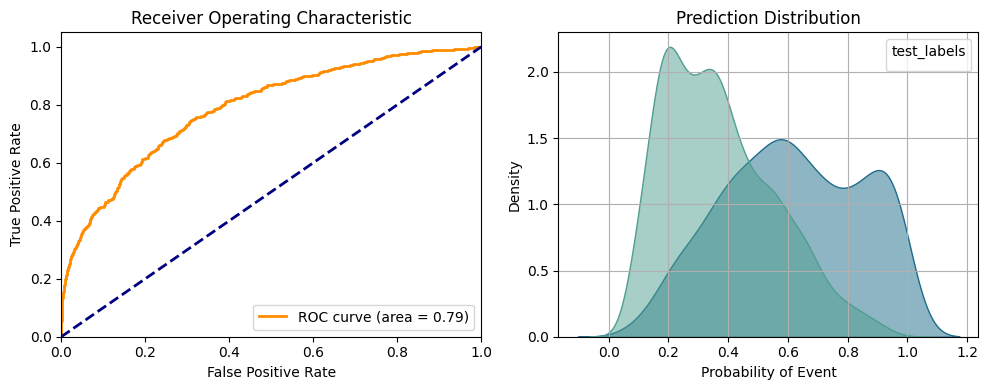

In [48]:
plot_roc_curve_from_df(model_1, test_labels, test_data, 5)

In [55]:
model_2, results_df_2, best_params_2 =  train_xgb_gridsearch_and_rank(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels)
results_df_2

Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 3 candidates, totalling 9 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [15:41:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 6
   min_child_weight: 1
   n_estimators: 200
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.7943


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [15:41:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Test,0.7483,0.6499,0.4059,0.4997,0.4352,0.7858,1
1,XGBClassifier (GridSearch),Holdout,0.7410,0.6569,0.4095,0.5045,0.4427,0.8032,2


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


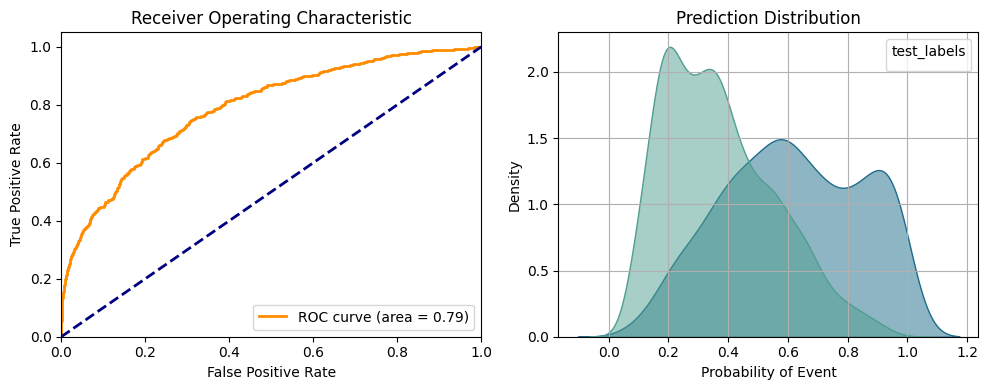

In [53]:
plot_roc_curve_from_df(model_2, test_labels, test_data, 5)

In [57]:
model_3, results_df_3, best_params_3 =  train_xgb_gridsearch_and_rank_v2(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels)
results_df_3

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [15:47:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 3
   min_child_weight: 1
   n_estimators: 1000
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.8007


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [15:47:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Test,0.8402,0.2861,0.7176,0.4091,0.4455,0.7913,1
1,XGBClassifier (GridSearch),Holdout,0.8323,0.2903,0.6972,0.4099,0.4569,0.8105,2


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


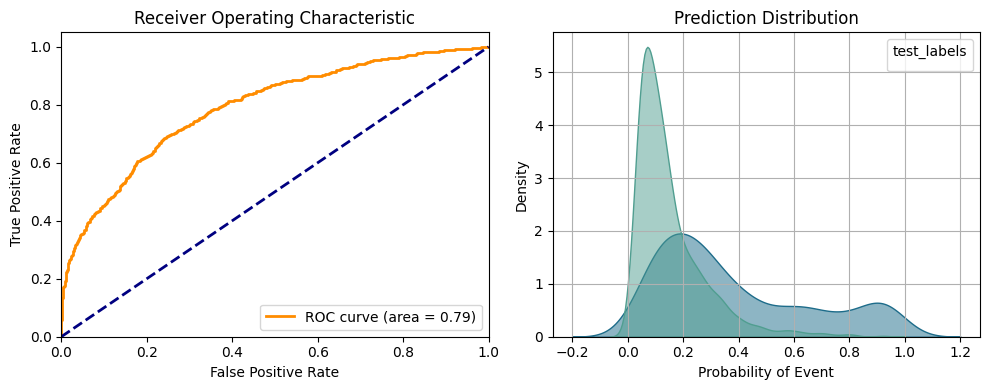

In [58]:
plot_roc_curve_from_df(model_3, test_labels, test_data, 5)

In [48]:
model_4, results_df_4, best_params_4 =  train_xgb_gridsearch_and_rank_v3(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels)
results_df_4

Fitting 3 folds for each of 12 candidates, totalling 36 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:11:29] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 3
   min_child_weight: 1
   n_estimators: 1000
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.8016


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:11:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Test,0.8402,0.2861,0.7176,0.4091,0.4455,0.7913,1
1,XGBClassifier (GridSearch),Holdout,0.8323,0.2903,0.6972,0.4099,0.4569,0.8105,2


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:235: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


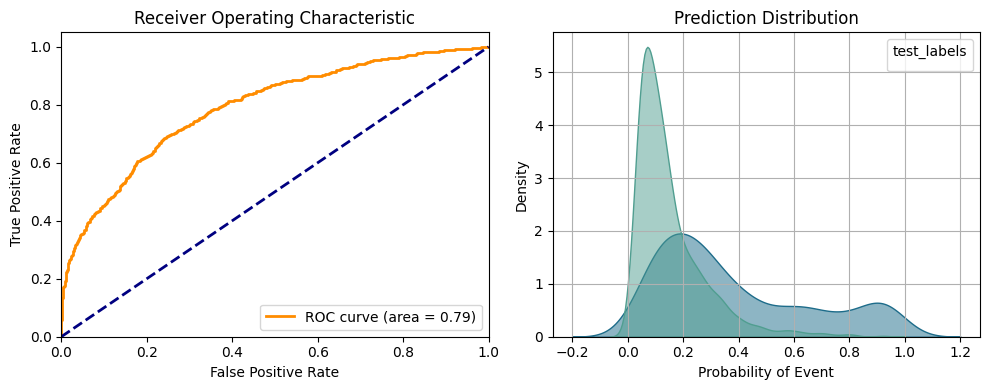

In [49]:
plot_roc_curve_from_df(model_4, test_labels, test_data, 5)

In [32]:
model_5, results_df_5, best_params_5 =  train_xgb_gridsearch_and_rank(train_data, train_labels, test_data, test_labels, holdout_data, holdout_labels)
results_df_5

Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 9 candidates, totalling 27 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:48:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 3
   min_child_weight: 1
   n_estimators: 800
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.7999


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [12:48:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Test,0.7401,0.6758,0.3986,0.5014,0.4383,0.7904,1
1,XGBClassifier (GridSearch),Holdout,0.7398,0.6950,0.4122,0.5175,0.4527,0.8093,2


c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:236: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


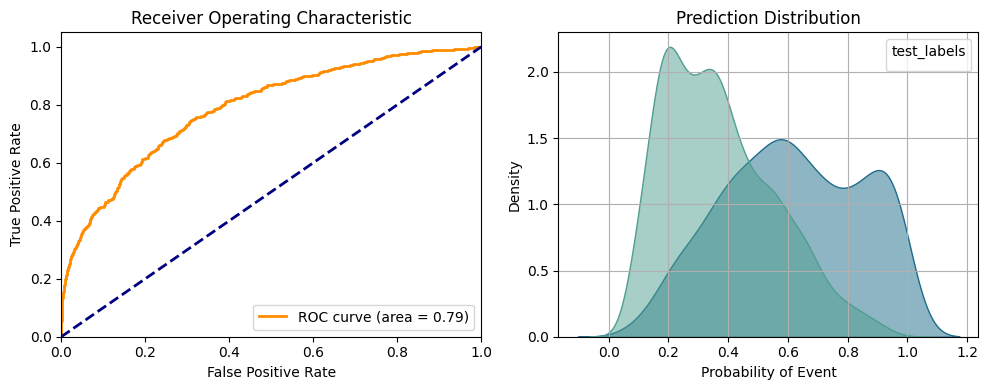

In [33]:
plot_roc_curve_from_df(model_5, test_labels, test_data, 5)

In [34]:

df_rank, result = perm_importance_test(
    model_5,
    test_data,
    test_labels,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

df_rank

🔹 Computing permutation importance on TEST set...
✅ Permutation importance completed on TEST dataset.


,rank,feature,importance_mean,importance_std
0,1,REC41_M14,8.026497e-02,3.593984e-03
1,2,REC41_M18_4,2.617838e-02,4.570660e-03
2,3,REC41_M17,2.595690e-02,5.068371e-03
3,4,REC94_S410B_7,2.386259e-02,2.263472e-03
4,5,REC41_M18_5,1.379623e-02,1.554908e-03
5,6,REC41_M13,1.257330e-02,2.982889e-03
6,7,REC91_SREGION,5.893966e-03,2.366559e-03
7,8,REC41_M3A,1.942556e-03,9.922427e-04
8,9,REC41_M18_2,1.744326e-03,1.794419e-03
9,10,REC94_S411BA,1.272484e-03,2.793287e-04


In [36]:
save_file(df_rank, dir = "outputs\\reports", output_file = "df_rank_model_5.csv")

In [ ]:
TOP50_model_5 =[
'_M14',
'_S410B',
'_M13',
'_SREGION',
'_S411BA',
'_S410B',
'_S411CA',
'_S411EA',
'_M57M',
'_M47',
'_S413',
'_M15',
'_V732',
'_QS102',
'_M57E',
'_QS207C',
'_S411DA',
'_S411K',
'_V715',
'_M1B',
'_V704',
'_M47',
'_M1',
'_M57O',
'_QS27',
'_S411DA',
'_S108N',
'_M48',
'_S119',
'_V525',
'_QS27',
'_M10',
'_M1A',
'_V743F',
'_QI422A',
'_M11',
'_V721',
'_S411DA',
'_M15',
]

# keep all columns where name contains any of the patterns
#pattern = '|'.join([f'^{x}' for x in TOP50_model_5])  # start-with pattern
pattern = '|'.join(TOP50_model_5)

train_data_top50 = train_data.filter(regex=pattern, axis=1)
test_data_top50  = test_data.filter(regex=pattern, axis=1)
holdout_data_top50  = holdout_data.filter(regex=pattern, axis=1)

model_6, results_df_6, best_params_6 =  train_xgb_gridsearch_and_rank(train_data_top50,
                                                                      train_labels,
                                                                      test_data_top50,
                                                                      test_labels, 
                                                                      holdout_data_top50, 
                                                                      holdout_labels)
results_df_6


## BEST MODEL


Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 9 candidates, totalling 27 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [22:06:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 3
   min_child_weight: 1
   n_estimators: 1000
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.7997


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [22:06:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Model,dataset_type,Accuracy,Recall,Precision,F1 Score,KS Stat,ROC AUC,Rank
0,XGBClassifier (GridSearch),Training,0.7671,0.7199,0.4379,0.5446,0.5035,0.8325,1
1,XGBClassifier (GridSearch),Test,0.7433,0.6804,0.4031,0.5062,0.4461,0.7920,2
2,XGBClassifier (GridSearch),Holdout,0.7393,0.6950,0.4115,0.5169,0.4537,0.8081,3


In [76]:
best_params_6

{'colsample_bytree': 0.8,
 'gamma': 0,
 'learning_rate': 0.01,
 'max_depth': 3,
 'min_child_weight': 1,
 'n_estimators': 1000,
 'subsample': 0.8}

c:\Users\linoc\OneDrive\Encoder\03_partos\02_scripts\Premature_model\scripts\modeling.py:236: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(title='test_labels')


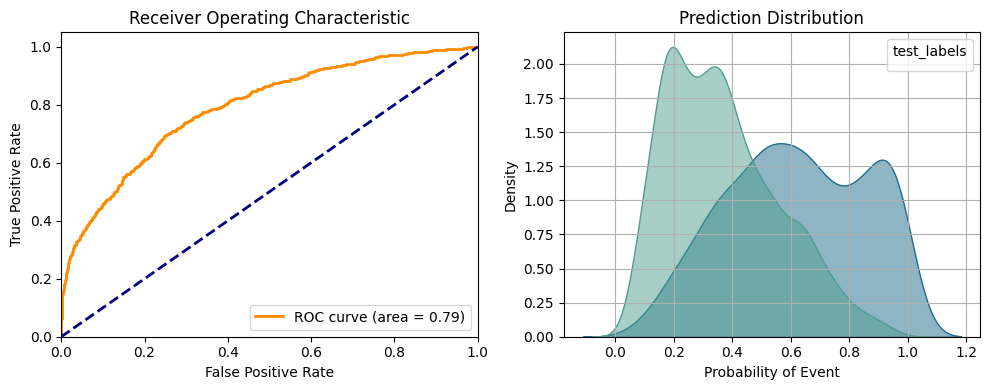

In [64]:
plot_roc_curve_from_df(model_6, test_labels, test_data_top50, 5)

[0]	validation_0-logloss:0.69151	validation_0-error:0.22739	validation_1-logloss:0.69157	validation_1-error:0.22903
[1]	validation_0-logloss:0.68990	validation_0-error:0.23740	validation_1-logloss:0.68994	validation_1-error:0.24522
[2]	validation_0-logloss:0.68830	validation_0-error:0.25053	validation_1-logloss:0.68828	validation_1-error:0.25434
[3]	validation_0-logloss:0.68703	validation_0-error:0.24716	validation_1-logloss:0.68706	validation_1-error:0.25346
[4]	validation_0-logloss:0.68560	validation_0-error:0.25305	validation_1-logloss:0.68564	validation_1-error:0.25787
[5]	validation_0-logloss:0.68403	validation_0-error:0.25381	validation_1-logloss:0.68412	validation_1-error:0.25787
[6]	validation_0-logloss:0.68269	validation_0-error:0.25364	validation_1-logloss:0.68278	validation_1-error:0.25787
[7]	validation_0-logloss:0.68122	validation_0-error:0.25389	validation_1-logloss:0.68138	validation_1-error:0.25905
[8]	validation_0-logloss:0.67977	validation_0-error:0.27316	validation_1

c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [22:40:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[27]	validation_0-logloss:0.65635	validation_0-error:0.26146	validation_1-logloss:0.65748	validation_1-error:0.27259
[28]	validation_0-logloss:0.65527	validation_0-error:0.26146	validation_1-logloss:0.65644	validation_1-error:0.27259
[29]	validation_0-logloss:0.65418	validation_0-error:0.26163	validation_1-logloss:0.65543	validation_1-error:0.27289
[30]	validation_0-logloss:0.65305	validation_0-error:0.26138	validation_1-logloss:0.65443	validation_1-error:0.27289
[31]	validation_0-logloss:0.65208	validation_0-error:0.26146	validation_1-logloss:0.65346	validation_1-error:0.27259
[32]	validation_0-logloss:0.65083	validation_0-error:0.26138	validation_1-logloss:0.65233	validation_1-error:0.27318
[33]	validation_0-logloss:0.64975	validation_0-error:0.26121	validation_1-logloss:0.65125	validation_1-error:0.27318
[34]	validation_0-logloss:0.64853	validation_0-error:0.26171	validation_1-logloss:0.65022	validation_1-error:0.27407
[35]	validation_0-logloss:0.64739	validation_0-error:0.26769	val

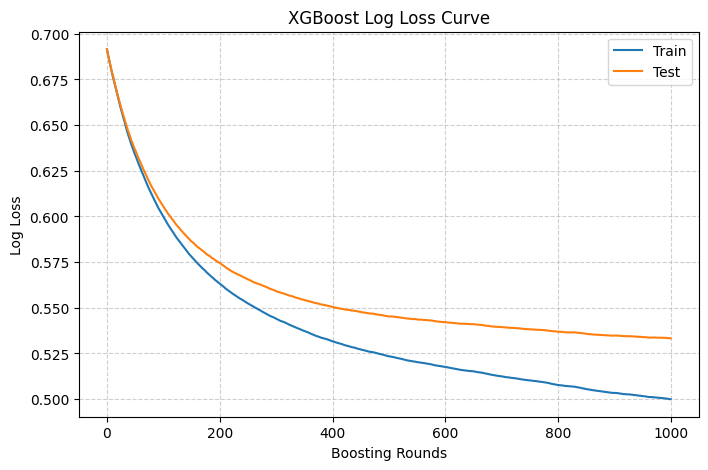

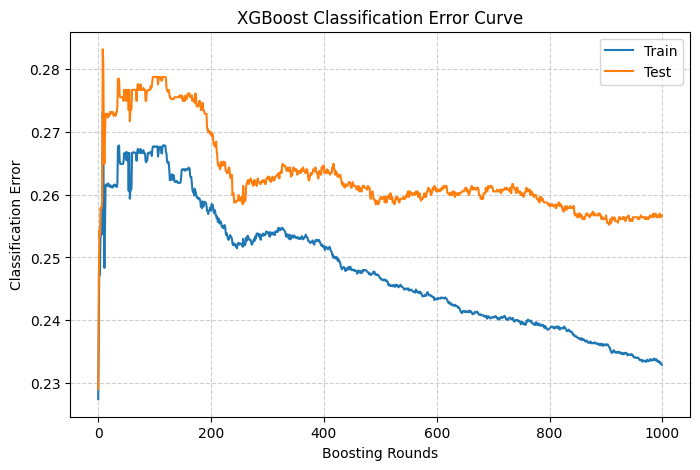

In [72]:
model_curve_plot_logloss_error(model_6, train_data_top50, train_labels, test_data_top50, test_labels)

In [74]:

model_7, results_df_7, best_params_7 =  train_xgb_gridsearch_and_rank(train_data_top50,
                                                                      train_labels,
                                                                      test_data_top50,
                                                                      test_labels, 
                                                                      holdout_data_top50, 
                                                                      holdout_labels, 
                                                                      early_stopping_rounds=400
                                                                      )
results_df_7

Class imbalance ratio (scale_pos_weight): 4.17
Fitting 3 folds for each of 9 candidates, totalling 27 fits


c:\Users\linoc\AppData\Local\Programs\Python\Python39\lib\site-packages\xgboost\core.py:158: UserWarning: [22:53:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Best Parameters Found:
   colsample_bytree: 0.8
   gamma: 0
   learning_rate: 0.01
   max_depth: 3
   min_child_weight: 1
   n_estimators: 1000
   subsample: 0.8
🏆 Best CV ROC-AUC: 0.7997


TypeError: fit() got an unexpected keyword argument 'early_stopping_rounds'

In [ ]:
df_rank_model_7, result_model_7 = perm_importance_test(
    model_7,
    test_data,
    test_labels,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

df_rank_model_6

🔹 Computing permutation importance on TEST set...


ValueError: feature_names mismatch: ['REC91_SREGION', 'REC91_S108N', 'REC91_S119', 'REC91_S119D', 'RE516171_V704', 'RE516171_V715', 'RE516171_V732', 'RE516171_V743F', 'RE516171_V525', 'RE516171_V721', 'REC41_M11', 'REC41_M13', 'REC41_M14', 'REC41_M17', 'REC41_M57E', 'REC41_M57M', 'REC41_M57O', 'REC41_M1_0', 'REC41_M1_1', 'REC41_M1_2', 'REC41_M1_3', 'REC41_M1_4', 'REC41_M1_5', 'REC41_M1_7', 'REC41_M1_8', 'REC41_M1_NA', 'REC41_M1A_0', 'REC41_M1A_1', 'REC41_M1A_2', 'REC41_M1A_3', 'REC41_M1A_4', 'REC41_M1A_5', 'REC41_M1A_6', 'REC41_M1A_7', 'REC41_M1A_8', 'REC41_M1A_NA', 'REC41_M1B_1', 'REC41_M1B_10', 'REC41_M1B_11', 'REC41_M1B_12', 'REC41_M1B_2', 'REC41_M1B_3', 'REC41_M1B_4', 'REC41_M1B_5', 'REC41_M1B_6', 'REC41_M1B_7', 'REC41_M1B_8', 'REC41_M1B_9', 'REC41_M1B_98', 'REC41_M1B_NA', 'REC41_M1D_1', 'REC41_M1D_10', 'REC41_M1D_11', 'REC41_M1D_12', 'REC41_M1D_13', 'REC41_M1D_14', 'REC41_M1D_15', 'REC41_M1D_16', 'REC41_M1D_17', 'REC41_M1D_18', 'REC41_M1D_2', 'REC41_M1D_20', 'REC41_M1D_22', 'REC41